# Data Cleaning & Exploratory Data Analysis (EDA)


## Objective

The purpose of this notebook is to clean the dataset and perform exploratory data analysis (EDA)
to better understand user behavior related to advertisements.

EDA helps identify patterns, anomalies, and relationships between variables
before proceeding to feature engineering and modeling.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [8]:
url = "https://raw.githubusercontent.com/ameenmanna8824/DATASETS/main/Social_Network_Ads.csv"
data = pd.read_csv(url)
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## Missing Values Analysis

Missing values can introduce bias or reduce model performance.
This section examines the presence and extent of missing data.


In [5]:
data.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


### Missing Value Insights

- Features with a high number of missing values may require removal or imputation.
- The impact of missing data will be evaluated in later steps.


## Outlier Analysis

Outliers can distort statistical summaries and model performance.
Boxplots are used to visually inspect extreme values.


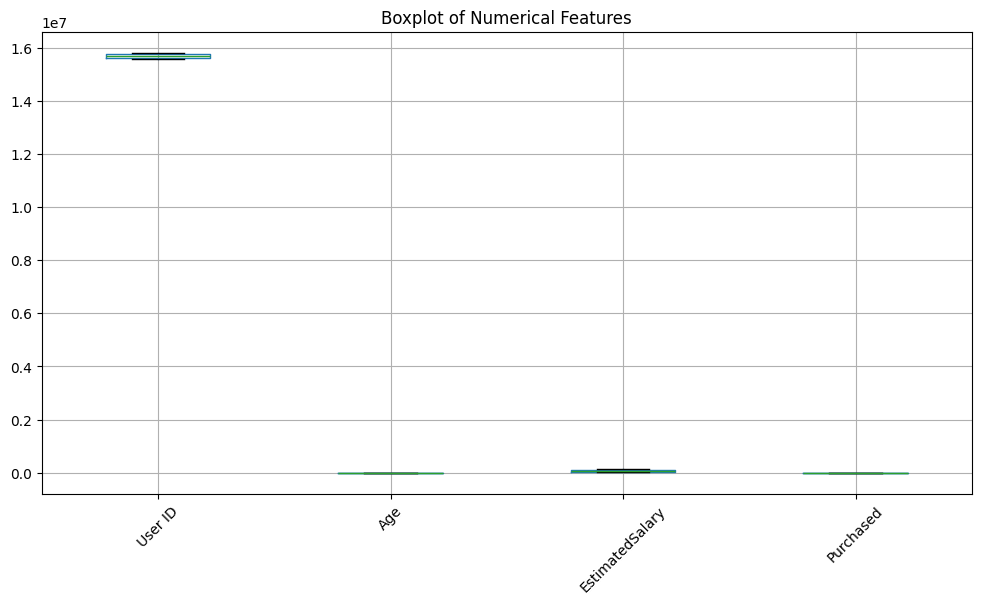

In [6]:
numerical_cols = data.select_dtypes(include=np.number).columns

plt.figure(figsize=(12, 6))
data[numerical_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()


## Univariate Analysis

This section analyzes individual features to understand their distributions.


In [10]:
data.columns


Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

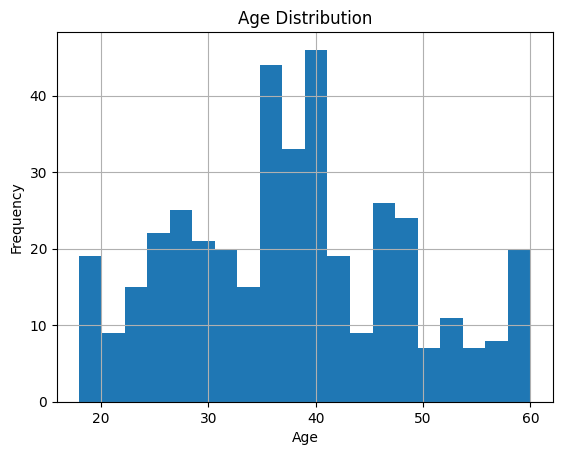

In [12]:
data["Age"].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

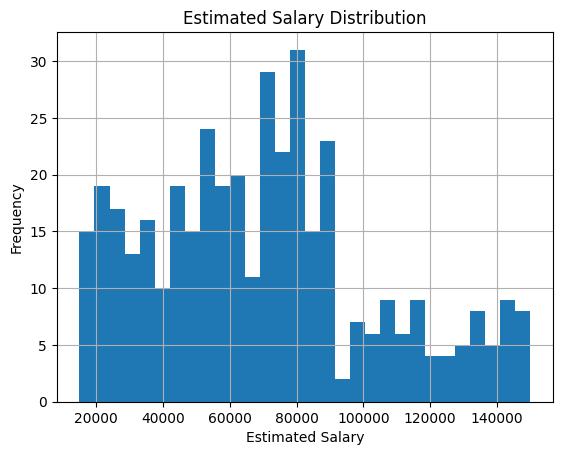

In [13]:
data["EstimatedSalary"].hist(bins=30)
plt.title("Estimated Salary Distribution")
plt.xlabel("Estimated Salary")
plt.ylabel("Frequency")
plt.show()

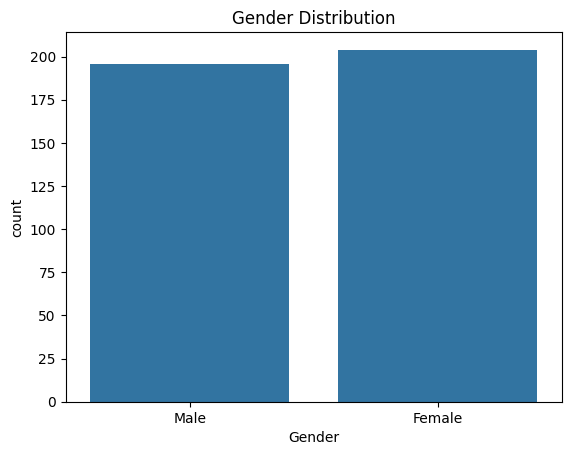

In [14]:
sns.countplot(x="Gender", data=data)
plt.title("Gender Distribution")
plt.show()


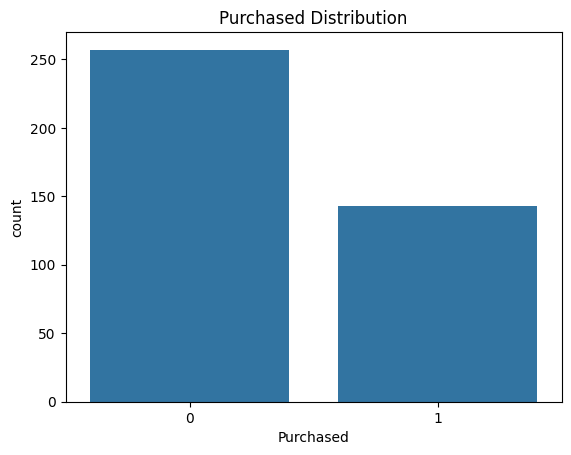

In [15]:
sns.countplot(x="Purchased", data=data)
plt.title("Purchased Distribution")
plt.show()


BIVARIATE ANALYSIS

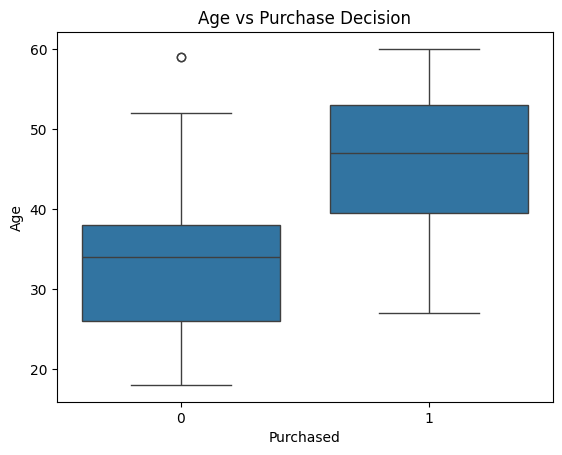

In [16]:
sns.boxplot(x="Purchased", y="Age", data=data)
plt.title("Age vs Purchase Decision")
plt.show()

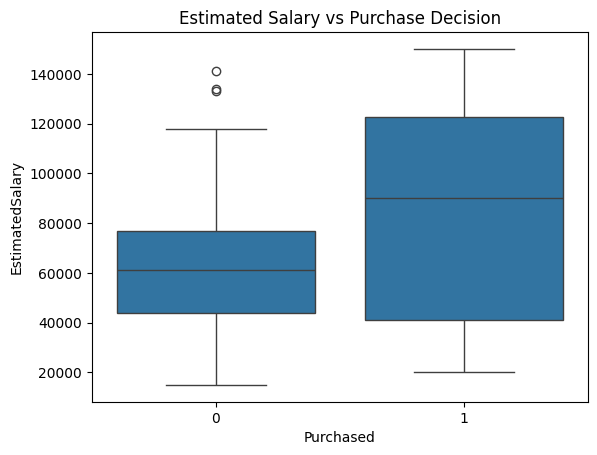

In [17]:
sns.boxplot(x="Purchased", y="EstimatedSalary", data=data)
plt.title("Estimated Salary vs Purchase Decision")
plt.show()


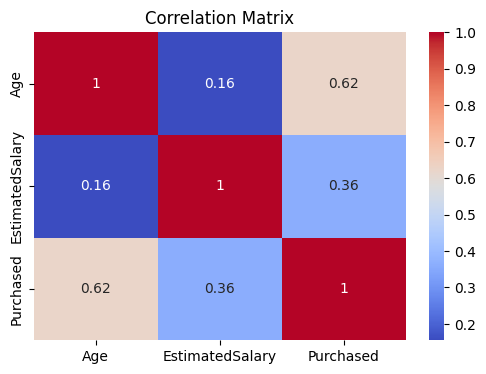

In [18]:
plt.figure(figsize=(6,4))
sns.heatmap(data[["Age", "EstimatedSalary", "Purchased"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


User ID is an identifier and does not carry predictive information.
It will be removed in the feature engineering stage.


## Key Insights from EDA

- Age appears to have a significant influence on purchase behavior.
- Higher estimated salaries are associated with increased purchase likelihood.
- Gender shows slight imbalance but requires encoding for modeling.
- The target variable is binary, making this a classification problem.

